# Análisis Exploratorio de Datos (EDA) - SARFIRE-GIF

## Objetivo del EDA

Este notebook tiene como objetivo realizar un análisis exploratorio exhaustivo de los datos históricos de incendios forestales en España (1968-2023) y los índices meteorológicos FWI (Fire Weather Index).

**Objetivos específicos:**
- Comprender la estructura y calidad de los datos disponibles
- Identificar patrones temporales y geográficos en los incendios
- Analizar la relación entre variables meteorológicas (FWI) y la ocurrencia de Grandes Incendios Forestales (GIF)
- Detectar problemas de datos (valores nulos, outliers, inconsistencias)
- Preparar el terreno para el preprocesamiento y modelado posterior

## Descripción de los Datasets

### 1. Dataset de Incendios Forestales (`incendios_1968_2023.csv`)
- **Fuente:** Civio - Incendios Forestales en España
- **Período:** 1968-2023 (55 años)
- **Registros:** ~292,000 incendios
- **Variables principales:**
  - Fecha y hora de inicio
  - Ubicación geográfica (provincia)
  - Superficie afectada (hectáreas)
  - Tipo de vegetación
  - Causa probable
  - Costes de extinción (cuando disponible)

### 2. Dataset FWI (`fwi_historico.csv`)
- **Fuente:** Civio - Índice de Riesgo Meteorológico
- **Período:** Histórico (coincidente con incendios)
- **Registros:** ~19 millones de registros diarios
- **Variables principales:**
  - **FWI** (Fire Weather Index): Índice general de riesgo meteorológico (único índice disponible)
  - **x, y**: Coordenadas geográficas
  - **date**: Fecha del registro
- **Granularidad:** Diaria por coordenadas (x, y)
- **Nota:** Este dataset NO contiene los componentes individuales del FWI (ISI, BUI, FFMC, DMC, DC), solo el índice agregado FWI

---

**Nota:** Los datos deben estar descargados en `data/raw/` antes de ejecutar este notebook.

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Configuración de visualización
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Librerías importadas correctamente")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")

✅ Librerías importadas correctamente
📊 Pandas version: 3.0.0
📈 Matplotlib version: 3.10.8
🎨 Seaborn version: 0.13.2


## 2. CARGA DE DATOS

En esta sección cargamos ambos datasets desde los archivos CSV ubicados en `data/raw/`.

In [2]:
# Definir rutas de los archivos
data_dir = Path('../data/raw')
incendios_path = data_dir / 'incendios_1968_2023.csv'
fwi_path = data_dir / 'fwi_historico.csv'

# Verificar que los archivos existen
if not incendios_path.exists():
    raise FileNotFoundError(f"❌ No se encontró el archivo: {incendios_path}")
if not fwi_path.exists():
    raise FileNotFoundError(f"❌ No se encontró el archivo: {fwi_path}")

print("✅ Archivos encontrados")
print(f"📁 Incendios: {incendios_path}")
print(f"📁 FWI: {fwi_path}")

✅ Archivos encontrados
📁 Incendios: ../data/raw/incendios_1968_2023.csv
📁 FWI: ../data/raw/fwi_historico.csv


In [3]:
# Cargar dataset de incendios
print("📥 Cargando dataset de incendios...")
df_incendios = pd.read_csv(incendios_path, low_memory=False)
print(f"✅ Dataset de incendios cargado: {len(df_incendios):,} registros")

# Parsear fecha en dataset de incendios
if 'fecha' in df_incendios.columns:
    df_incendios['fecha'] = pd.to_datetime(df_incendios['fecha'], errors='coerce')
    print(f"✅ Columna 'fecha' parseada a datetime")

# Cargar dataset FWI (puede tardar debido al tamaño)
print("\n📥 Cargando dataset FWI...")
df_fwi = pd.read_csv(fwi_path, low_memory=False)
print(f"✅ Dataset FWI cargado: {len(df_fwi):,} registros")

# Parsear fecha en dataset FWI
if 'date' in df_fwi.columns:
    df_fwi['date'] = pd.to_datetime(df_fwi['date'], errors='coerce')
    print(f"✅ Columna 'date' parseada a datetime")

📥 Cargando dataset de incendios...
✅ Dataset de incendios cargado: 292,181 registros
✅ Columna 'fecha' parseada a datetime

📥 Cargando dataset FWI...
✅ Dataset FWI cargado: 19,296,888 registros
✅ Columna 'date' parseada a datetime


In [4]:
# Mostrar primeras filas del dataset de incendios
print("=" * 80)
print("PRIMERAS FILAS - DATASET DE INCENDIOS")
print("=" * 80)
df_incendios.head(10)

PRIMERAS FILAS - DATASET DE INCENDIOS


,id,superficie,fecha,lat,lng,latlng_explicit,idcomunidad,idprovincia,idmunicipio,municipio,causa,causa_supuesta,causa_desc,muertos,heridos,time_ctrl,time_ext,personal,medios,gastos,perdidas
0,1968290001,14.00,1968-01-01,NaN,NaN,NaN,4,29,0,INDETERMINADO,2,1,40,0,0,0,360,0,0,0,0
1,1968430003,3.00,1968-01-03,NaN,NaN,NaN,2,43,0,INDETERMINADO,5,1,0,0,0,0,60,0,0,0,0
2,1968290006,2.00,1968-01-06,NaN,NaN,NaN,4,29,0,INDETERMINADO,5,1,0,0,0,0,120,0,0,0,0
3,1968120007,8.20,1968-01-07,NaN,NaN,NaN,9,12,0,INDETERMINADO,3,1,20,0,0,0,120,0,0,0,0
4,1968430016,600.00,1968-01-07,NaN,NaN,NaN,2,43,0,INDETERMINADO,3,1,20,0,0,0,1440,35,1,0,0
5,1968460044,1.00,1968-01-07,NaN,NaN,NaN,9,46,0,INDETERMINADO,5,1,0,0,0,0,120,0,0,0,0
6,1968430004,1.80,1968-01-09,NaN,NaN,NaN,2,43,0,INDETERMINADO,2,1,40,0,0,0,120,0,0,0,0
7,1968440009,1.50,1968-01-09,NaN,NaN,NaN,10,44,0,INDETERMINADO,2,1,40,0,0,0,120,0,0,0,0
8,1968250010,35.00,1968-01-10,NaN,NaN,NaN,2,25,0,INDETERMINADO,4,1,99,0,0,0,1440,39,0,0,0
9,1968490017,1.00,1968-01-10,NaN,NaN,NaN,17,49,0,INDETERMINADO,2,1,40,0,0,0,60,0,0,0,0


In [5]:
# Mostrar primeras filas del dataset FWI
print("=" * 80)
print("PRIMERAS FILAS - DATASET FWI")
print("=" * 80)
df_fwi.head(10)

PRIMERAS FILAS - DATASET FWI


,x,y,date,fwi
0,-8.25,43.75,1971-01-01,0.01
1,-8.25,43.75,1971-01-02,0.24
2,-8.25,43.75,1971-01-03,0.55
3,-8.25,43.75,1971-01-04,3.05
4,-8.25,43.75,1971-01-05,0.03
5,-8.25,43.75,1971-01-06,0.38
6,-8.25,43.75,1971-01-07,0.64
7,-8.25,43.75,1971-01-08,4.60
8,-8.25,43.75,1971-01-09,3.50
9,-8.25,43.75,1971-01-10,2.30


## 3. INSPECCIÓN BÁSICA

Realizamos una inspección básica de ambos datasets para entender su estructura, tipos de datos, y detectar problemas iniciales.

In [6]:
# Información básica del dataset de incendios
print("=" * 80)
print("INFORMACIÓN BÁSICA - DATASET DE INCENDIOS")
print("=" * 80)
print(f"\n📊 Shape: {df_incendios.shape[0]:,} filas × {df_incendios.shape[1]} columnas")
print(f"\n📋 Columnas:")
for i, col in enumerate(df_incendios.columns, 1):
    print(f"  {i}. {col}")

print("\n" + "=" * 80)
print("TIPOS DE DATOS")
print("=" * 80)
print(df_incendios.dtypes)

INFORMACIÓN BÁSICA - DATASET DE INCENDIOS

📊 Shape: 292,181 filas × 21 columnas

📋 Columnas:
  1. id
  2. superficie
  3. fecha
  4. lat
  5. lng
  6. latlng_explicit
  7. idcomunidad
  8. idprovincia
  9. idmunicipio
  10. municipio
  11. causa
  12. causa_supuesta
  13. causa_desc
  14. muertos
  15. heridos
  16. time_ctrl
  17. time_ext
  18. personal
  19. medios
  20. gastos
  21. perdidas

TIPOS DE DATOS
id                          int64
superficie                float64
fecha              datetime64[us]
lat                       float64
lng                       float64
latlng_explicit           float64
idcomunidad                 int64
idprovincia                 int64
idmunicipio                 int64
municipio                     str
causa                       int64
causa_supuesta              int64
causa_desc                  int64
muertos                     int64
heridos                     int64
time_ctrl                   int64
time_ext                    int64
persona

In [7]:
# Resumen estadístico del dataset de incendios
print("=" * 80)
print("RESUMEN ESTADÍSTICO - DATASET DE INCENDIOS")
print("=" * 80)
df_incendios.describe()

RESUMEN ESTADÍSTICO - DATASET DE INCENDIOS


,id,superficie,fecha,lat,lng,latlng_explicit,idcomunidad,idprovincia,idmunicipio,causa,causa_supuesta,causa_desc,muertos,heridos,time_ctrl,time_ext,personal,medios,gastos,perdidas
count,292181.00,292181.00,292181,237746.00,237746.00,237788.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00,292181.00
mean,1995165915.07,26.75,1995-05-20 02:26:31.076764,41.69,-5.75,0.36,7.28,27.55,61.75,3.88,0.82,39.02,0.00,0.01,132.99,520.79,22.09,2.07,593.28,8461.07
min,1968020089.00,1.00,1968-01-01 00:00:00,27.71,-18.15,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,-1430.00,-1352.00,0.00,0.00,0.00,0.00
25%,1985491869.00,1.80,1985-10-29 00:00:00,40.86,-7.55,0.00,3.00,17.00,9.00,4.00,1.00,0.00,0.00,0.00,0.00,140.00,5.00,0.00,0.00,0.00
50%,1995150346.00,3.50,1995-03-23 00:00:00,42.34,-6.32,0.00,5.00,32.00,39.00,4.00,1.00,10.00,0.00,0.00,0.00,240.00,12.00,1.00,0.00,0.00
75%,2004330435.00,10.10,2004-07-30 00:00:00,43.05,-4.42,1.00,12.00,36.00,80.00,5.00,1.00,99.00,0.00,0.00,130.00,480.00,25.00,2.00,0.00,186.00
max,2023420016.00,28879.10,2023-12-08 00:00:00,43.77,4.27,1.00,18.00,51.00,999.00,6.00,1.00,99.00,20.00,30.00,175794.00,175834.00,3587.00,438.00,2382923.00,54844893.00
std,12463453.59,228.91,NaN,1.95,2.55,0.48,5.45,11.78,90.50,1.06,0.39,44.58,0.06,0.15,688.69,1345.24,44.01,4.89,11784.72,230366.52


In [8]:
# Resumen estadístico del dataset FWI
print("=" * 80)
print("RESUMEN ESTADÍSTICO - DATASET FWI")
print("=" * 80)
df_fwi.describe()

RESUMEN ESTADÍSTICO - DATASET FWI


,x,y,date,fwi
count,19296888.00,19296888.00,19296888,19296888.00
mean,-3.88,39.92,1996-12-31 00:00:00,12.98
min,-18.00,27.75,1971-01-01 00:00:00,0.00
25%,-6.00,38.50,1984-01-01 00:00:00,0.84
50%,-3.75,40.50,1996-12-31 00:00:00,6.47
75%,-1.50,42.00,2009-12-31 00:00:00,20.88
max,4.25,43.75,2022-12-31 00:00:00,119.77
std,3.71,3.04,NaN,15.19


In [9]:
# Información detallada con .info() para incendios
print("=" * 80)
print("INFO DETALLADO - DATASET DE INCENDIOS")
print("=" * 80)
df_incendios.info()

INFO DETALLADO - DATASET DE INCENDIOS
<class 'pandas.DataFrame'>
RangeIndex: 292181 entries, 0 to 292180
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id               292181 non-null  int64         
 1   superficie       292181 non-null  float64       
 2   fecha            292181 non-null  datetime64[us]
 3   lat              237746 non-null  float64       
 4   lng              237746 non-null  float64       
 5   latlng_explicit  237788 non-null  float64       
 6   idcomunidad      292181 non-null  int64         
 7   idprovincia      292181 non-null  int64         
 8   idmunicipio      292181 non-null  int64         
 9   municipio        292181 non-null  str           
 10  causa            292181 non-null  int64         
 11  causa_supuesta   292181 non-null  int64         
 12  causa_desc       292181 non-null  int64         
 13  muertos          292181 non-null  int64        

In [10]:
# Información detallada con .info() para FWI
print("=" * 80)
print("INFO DETALLADO - DATASET FWI")
print("=" * 80)
df_fwi.info()

INFO DETALLADO - DATASET FWI
<class 'pandas.DataFrame'>
RangeIndex: 19296888 entries, 0 to 19296887
Data columns (total 4 columns):
 #   Column  Dtype         
---  ------  -----         
 0   x       float64       
 1   y       float64       
 2   date    datetime64[us]
 3   fwi     float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 588.9 MB


In [33]:
# Análisis de valores nulos en el dataset FWI
print("=" * 80)
print("ANÁLISIS DE VALORES NULOS - DATASET FWI")
print("=" * 80)

null_counts = df_fwi.isnull().sum()
null_percentages = (null_counts / len(df_fwi)) * 100

null_analysis = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_percentages
}).sort_values('Valores Nulos', ascending=False)

# Filtrar solo columnas con valores nulos
null_analysis = null_analysis[null_analysis['Valores Nulos'] > 0]

if len(null_analysis) > 0:
    print(null_analysis)
else:
    print("✅ No se encontraron valores nulos en el dataset FWI")

ANÁLISIS DE VALORES NULOS - DATASET FWI
✅ No se encontraron valores nulos en el dataset FWI


## 4. VARIABLE OBJETIVO

Creamos la variable objetivo **GIF (Grande Incendio Forestal)** definida como aquellos incendios que superan las 500 hectáreas afectadas. Esta es una clasificación binaria crítica para el modelo.

In [13]:
# Usar columna 'superficie' (nombre real en el dataset)
superficie_col = 'superficie'

if superficie_col in df_incendios.columns:
    print(f"✅ Columna de superficie encontrada: '{superficie_col}'")
    print(f"   Tipo de datos: {df_incendios[superficie_col].dtype}")
    print(f"   Valores nulos: {df_incendios[superficie_col].isnull().sum():,} ({df_incendios[superficie_col].isnull().sum()/len(df_incendios)*100:.2f}%)")
else:
    print(f"⚠️  Columna '{superficie_col}' no encontrada.")
    print(f"   Columnas disponibles: {list(df_incendios.columns)}")

✅ Columna de superficie encontrada: 'superficie'
   Tipo de datos: float64
   Valores nulos: 0 (0.00%)


In [14]:
# Crear variable objetivo GIF (Grande Incendio Forestal)
# Umbral: > 500 hectáreas
# NOTA: Ajustar 'superficie_col' según el nombre real de la columna en el dataset

# Verificar que la columna existe y tiene datos válidos
if superficie_col in df_incendios.columns:
    # Crear variable objetivo binaria
    df_incendios['GIF'] = (df_incendios[superficie_col] > 500).astype(int)
    
    print("✅ Variable objetivo 'GIF' creada")
    print(f"   Umbral: > 500 hectáreas")
    print(f"\n📊 Distribución de clases:")
    print(df_incendios['GIF'].value_counts().sort_index())
    print(f"\n📈 Porcentajes:")
    print(df_incendios['GIF'].value_counts(normalize=True).sort_index() * 100)
else:
    print(f"⚠️  Columna '{superficie_col}' no encontrada.")
    print("   Revisar el nombre real de la columna de superficie en el dataset")

✅ Variable objetivo 'GIF' creada
   Umbral: > 500 hectáreas

📊 Distribución de clases:
GIF
0    290200
1      1981
Name: count, dtype: int64

📈 Porcentajes:
GIF
0   99.32
1    0.68
Name: proportion, dtype: float64


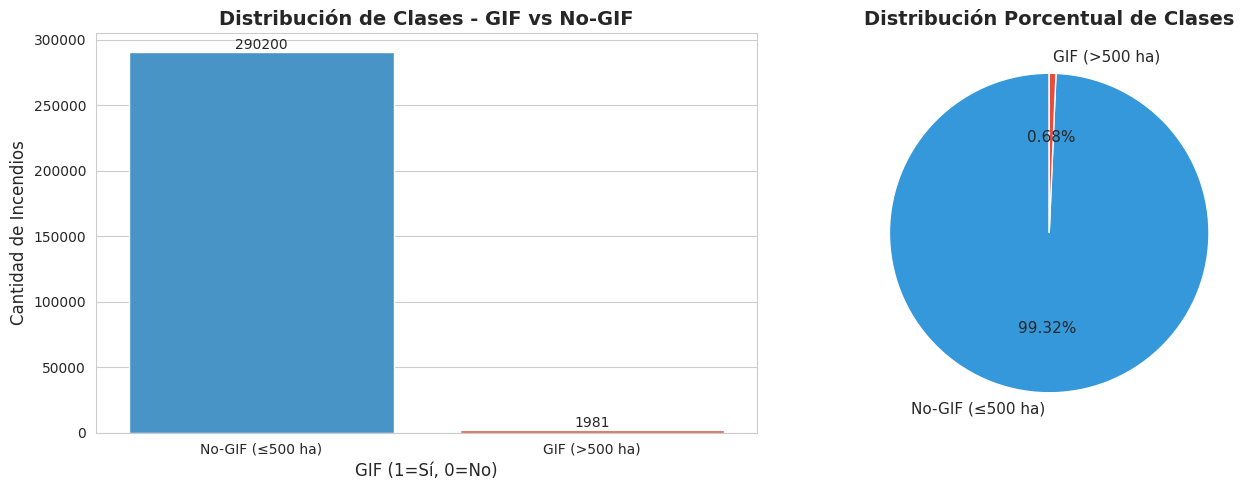


📊 Ratio de desbalanceo (No-GIF:GIF): 146.49:1
   Esto significa que hay 146.5 veces más incendios No-GIF que GIF


In [15]:
# Visualización de la distribución de clases
if 'GIF' in df_incendios.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Countplot
    sns.countplot(data=df_incendios, x='GIF', ax=axes[0], palette=['#3498db', '#e74c3c'])
    axes[0].set_title('Distribución de Clases - GIF vs No-GIF', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('GIF (1=Sí, 0=No)', fontsize=12)
    axes[0].set_ylabel('Cantidad de Incendios', fontsize=12)
    axes[0].set_xticklabels(['No-GIF (≤500 ha)', 'GIF (>500 ha)'])
    
    # Añadir valores en las barras
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%d', fontsize=10)
    
    # Gráfico de porcentajes
    class_counts = df_incendios['GIF'].value_counts(normalize=True) * 100
    axes[1].pie(class_counts.values, 
                labels=['No-GIF (≤500 ha)', 'GIF (>500 ha)'],
                autopct='%1.2f%%',
                colors=['#3498db', '#e74c3c'],
                startangle=90,
                textprops={'fontsize': 11})
    axes[1].set_title('Distribución Porcentual de Clases', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Calcular ratio de desbalanceo
    no_gif_count = (df_incendios['GIF'] == 0).sum()
    gif_count = (df_incendios['GIF'] == 1).sum()
    imbalance_ratio = no_gif_count / gif_count if gif_count > 0 else 0
    
    print(f"\n📊 Ratio de desbalanceo (No-GIF:GIF): {imbalance_ratio:.2f}:1")
    print(f"   Esto significa que hay {imbalance_ratio:.1f} veces más incendios No-GIF que GIF")

In [16]:
# Extraer variables temporales de la columna 'fecha'
fecha_col = 'fecha'

if fecha_col in df_incendios.columns:
    # La fecha ya fue parseada en la carga de datos
    # Extraer año y mes
    df_incendios['año'] = df_incendios[fecha_col].dt.year
    df_incendios['mes'] = df_incendios[fecha_col].dt.month
    df_incendios['dia_semana'] = df_incendios[fecha_col].dt.dayofweek
    df_incendios['estacion'] = df_incendios[fecha_col].dt.month.map({
        12: 'Invierno', 1: 'Invierno', 2: 'Invierno',
        3: 'Primavera', 4: 'Primavera', 5: 'Primavera',
        6: 'Verano', 7: 'Verano', 8: 'Verano',
        9: 'Otoño', 10: 'Otoño', 11: 'Otoño'
    })
    
    print("✅ Variables temporales creadas: año, mes, dia_semana, estacion")
    print(f"   Rango de fechas: {df_incendios[fecha_col].min()} a {df_incendios[fecha_col].max()}")
    print(f"   Fechas nulas: {df_incendios[fecha_col].isnull().sum():,}")
else:
    print(f"⚠️  Columna '{fecha_col}' no encontrada.")
    print(f"   Columnas disponibles: {list(df_incendios.columns)}")

✅ Variables temporales creadas: año, mes, dia_semana, estacion
   Rango de fechas: 1968-01-01 00:00:00 a 2023-12-08 00:00:00
   Fechas nulas: 0


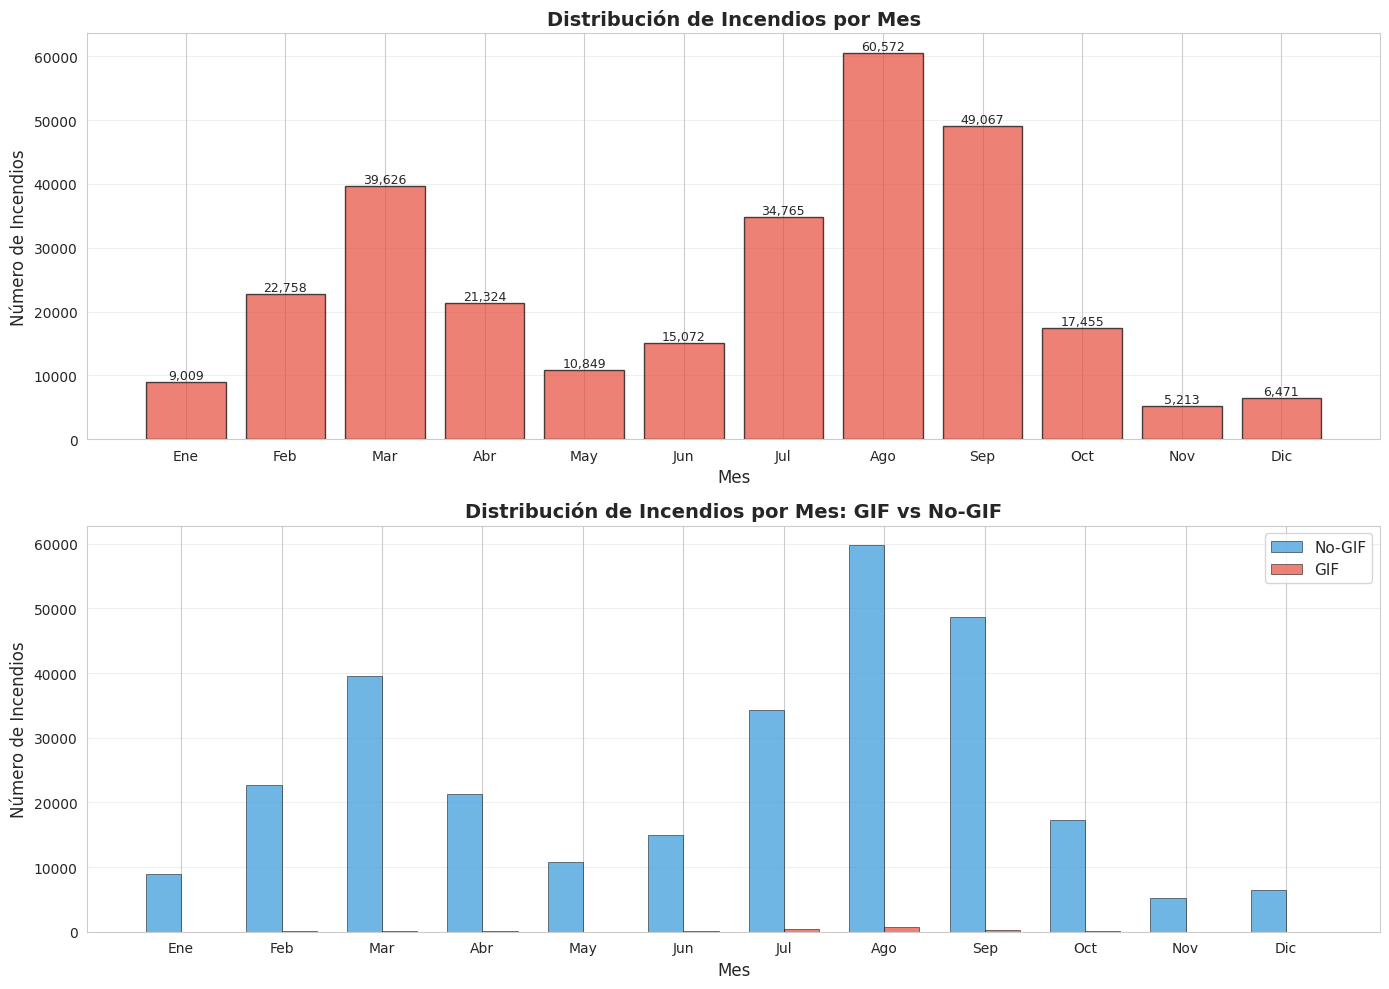


📊 Estadísticas por mes:
   Mes con más incendios: Ago (60,572 incendios)
   Mes con menos incendios: Nov (5,213 incendios)


In [17]:
# Distribución de incendios por mes
if 'mes' in df_incendios.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfico 1: Total de incendios por mes
    meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    incendios_por_mes = df_incendios.groupby('mes').size()
    
    axes[0].bar(incendios_por_mes.index, incendios_por_mes.values, 
                color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1)
    axes[0].set_title('Distribución de Incendios por Mes', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Mes', fontsize=12)
    axes[0].set_ylabel('Número de Incendios', fontsize=12)
    axes[0].set_xticks(range(1, 13))
    axes[0].set_xticklabels(meses_nombres)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Añadir valores en las barras
    for i, v in enumerate(incendios_por_mes.values):
        axes[0].text(i+1, v, f'{int(v):,}', ha='center', va='bottom', fontsize=9)
    
    # Gráfico 2: GIF vs No-GIF por mes
    gif_por_mes = df_incendios.groupby(['mes', 'GIF']).size().unstack(fill_value=0)
    if 1 in gif_por_mes.columns:
        x = np.arange(1, 13)
        width = 0.35
        axes[1].bar(x - width/2, gif_por_mes[0], width, label='No-GIF', 
                   color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[1].bar(x + width/2, gif_por_mes[1], width, label='GIF', 
                   color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[1].set_title('Distribución de Incendios por Mes: GIF vs No-GIF', 
                          fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Mes', fontsize=12)
        axes[1].set_ylabel('Número de Incendios', fontsize=12)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(meses_nombres)
        axes[1].legend(fontsize=11)
        axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Mes con más incendios
    print("\n📊 Estadísticas por mes:")
    print(f"   Mes con más incendios: {meses_nombres[incendios_por_mes.idxmax()-1]} ({incendios_por_mes.max():,} incendios)")
    print(f"   Mes con menos incendios: {meses_nombres[incendios_por_mes.idxmin()-1]} ({incendios_por_mes.min():,} incendios)")

## 5. ANÁLISIS TEMPORAL

Analizamos la distribución temporal de los incendios para identificar tendencias, estacionalidad y patrones a lo largo del tiempo.

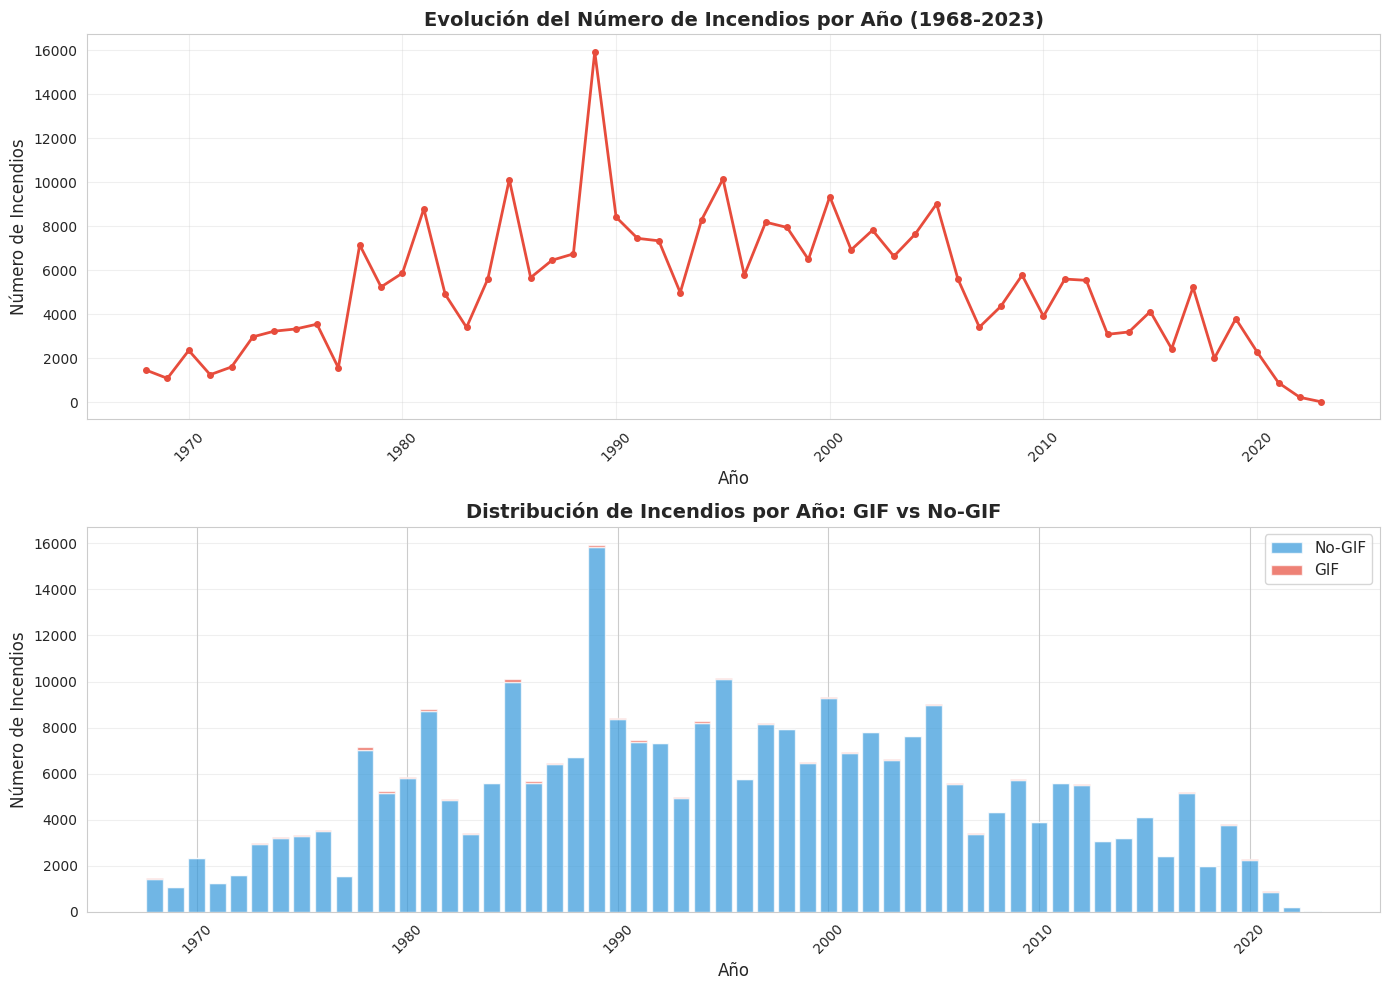


📊 Estadísticas por año:
   Año con más incendios: 1989 (15,922 incendios)
   Año con menos incendios: 2023 (23 incendios)
   Promedio anual: 5218 incendios


In [18]:
# Distribución de incendios por año
if 'año' in df_incendios.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfico 1: Total de incendios por año
    incendios_por_año = df_incendios.groupby('año').size()
    axes[0].plot(incendios_por_año.index, incendios_por_año.values, 
                 marker='o', linewidth=2, markersize=4, color='#e74c3c')
    axes[0].set_title('Evolución del Número de Incendios por Año (1968-2023)', 
                      fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Año', fontsize=12)
    axes[0].set_ylabel('Número de Incendios', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico 2: GIF vs No-GIF por año
    gif_por_año = df_incendios.groupby(['año', 'GIF']).size().unstack(fill_value=0)
    if 1 in gif_por_año.columns:
        axes[1].bar(gif_por_año.index, gif_por_año[0], label='No-GIF', color='#3498db', alpha=0.7)
        axes[1].bar(gif_por_año.index, gif_por_año[1], bottom=gif_por_año[0], 
                   label='GIF', color='#e74c3c', alpha=0.7)
        axes[1].set_title('Distribución de Incendios por Año: GIF vs No-GIF', 
                          fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Año', fontsize=12)
        axes[1].set_ylabel('Número de Incendios', fontsize=12)
        axes[1].legend(fontsize=11)
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas por año
    print("\n📊 Estadísticas por año:")
    print(f"   Año con más incendios: {incendios_por_año.idxmax()} ({incendios_por_año.max():,} incendios)")
    print(f"   Año con menos incendios: {incendios_por_año.idxmin()} ({incendios_por_año.min():,} incendios)")
    print(f"   Promedio anual: {incendios_por_año.mean():.0f} incendios")

In [34]:
# Ver distribución por año con detalle
year_counts = df_incendios.groupby(df_incendios['fecha'].dt.year).size()
print(year_counts)

# Ver específicamente 2023
print("\n🔍 Incendios en 2023:")
print(df_incendios[df_incendios['fecha'].dt.year == 2023]['fecha'].describe())

fecha
1968     1464
1969     1088
1970     2358
1971     1255
1972     1606
1973     2974
1974     3232
1975     3331
1976     3549
1977     1569
1978     7151
1979     5241
1980     5870
1981     8789
1982     4906
1983     3404
1984     5614
1985    10119
1986     5665
1987     6455
1988     6743
1989    15922
1990     8413
1991     7450
1992     7337
1993     4984
1994     8288
1995    10146
1996     5775
1997     8184
1998     7944
1999     6489
2000     9345
2001     6927
2002     7819
2003     6634
2004     7646
2005     9017
2006     5593
2007     3413
2008     4355
2009     5777
2010     3910
2011     5599
2012     5542
2013     3089
2014     3196
2015     4125
2016     2432
2017     5223
2018     2004
2019     3796
2020     2287
2021      888
2022      226
2023       23
dtype: int64

🔍 Incendios en 2023:
count                            23
mean     2023-06-10 18:46:57.391304
min             2023-01-18 00:00:00
25%             2023-03-23 12:00:00
50%             2023-04-29 00:0

## 6. ANÁLISIS GEOGRÁFICO

Analizamos la distribución geográfica de los incendios para identificar las provincias con mayor incidencia y riesgo de GIF.

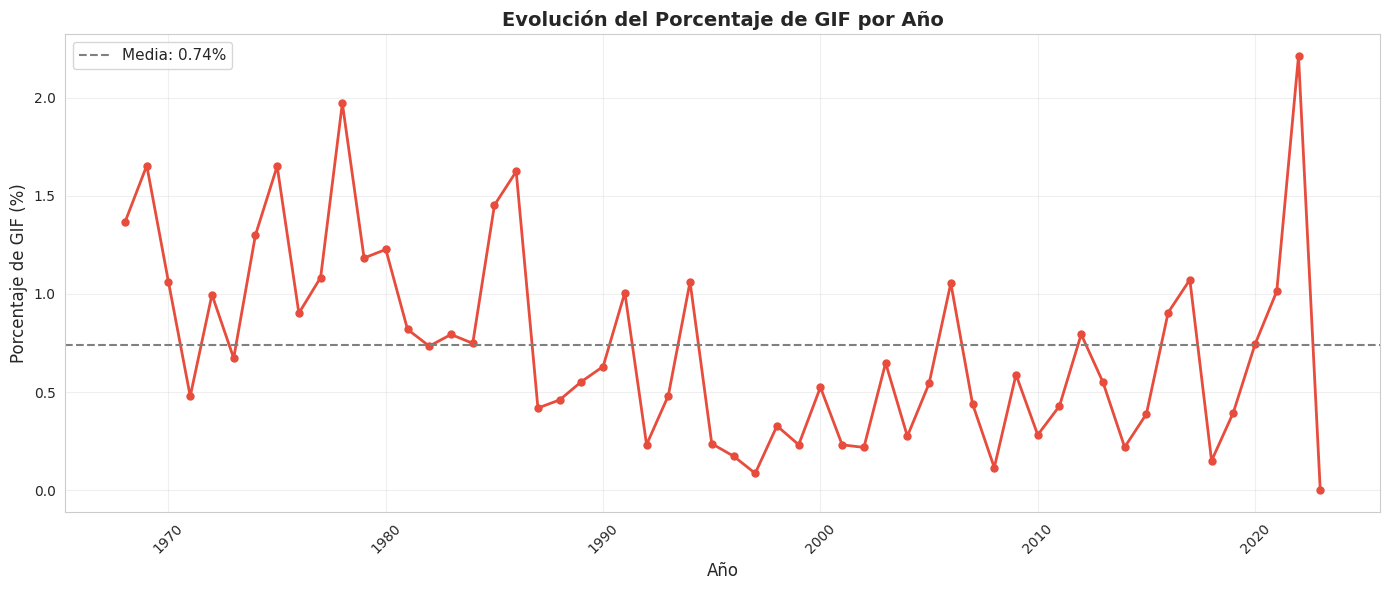


📈 Tendencias identificadas:
   Porcentaje promedio de GIF: 0.74%
   Año con mayor % de GIF: 2022 (2.21%)
   Año con menor % de GIF: 2023 (0.00%)


In [19]:
# Análisis de tendencias temporales
if 'año' in df_incendios.columns and 'GIF' in df_incendios.columns:
    # Calcular porcentaje de GIF por año
    porcentaje_gif_por_año = df_incendios.groupby('año')['GIF'].mean() * 100
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(porcentaje_gif_por_año.index, porcentaje_gif_por_año.values, 
            marker='o', linewidth=2, markersize=5, color='#e74c3c')
    ax.axhline(y=porcentaje_gif_por_año.mean(), color='gray', linestyle='--', 
               linewidth=1.5, label=f'Media: {porcentaje_gif_por_año.mean():.2f}%')
    ax.set_title('Evolución del Porcentaje de GIF por Año', fontsize=14, fontweight='bold')
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('Porcentaje de GIF (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("\n📈 Tendencias identificadas:")
    print(f"   Porcentaje promedio de GIF: {porcentaje_gif_por_año.mean():.2f}%")
    print(f"   Año con mayor % de GIF: {porcentaje_gif_por_año.idxmax()} ({porcentaje_gif_por_año.max():.2f}%)")
    print(f"   Año con menor % de GIF: {porcentaje_gif_por_año.idxmin()} ({porcentaje_gif_por_año.min():.2f}%)")

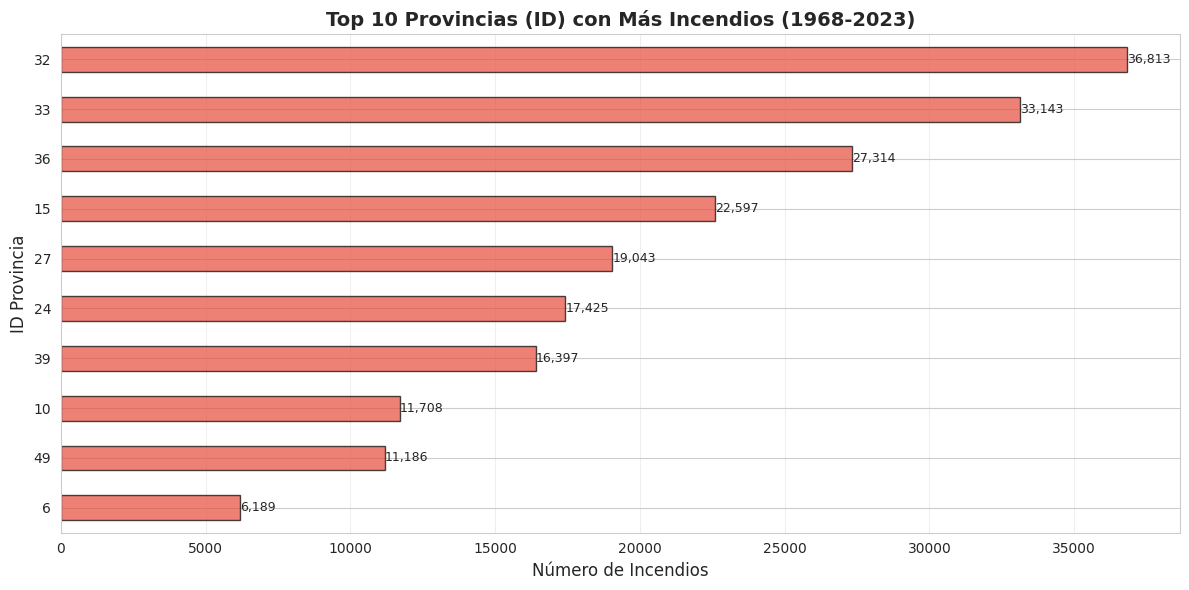


📊 Top 10 provincias (por ID) con más incendios:
   1. ID 32: 36,813 incendios
   2. ID 33: 33,143 incendios
   3. ID 36: 27,314 incendios
   4. ID 15: 22,597 incendios
   5. ID 27: 19,043 incendios
   6. ID 24: 17,425 incendios
   7. ID 39: 16,397 incendios
   8. ID 10: 11,708 incendios
   9. ID 49: 11,186 incendios
   10. ID 6: 6,189 incendios

📊 Top 10 municipios con más incendios:
   1. INDETERMINADO: 54,382 incendios
   2. CANGAS DEL NARCEA: 2,261 incendios
   3. PILOÑA: 2,109 incendios
   4. TINEO: 1,812 incendios
   5. VIANA DO BOLO: 1,716 incendios
   6. LLANES: 1,614 incendios
   7. GUDIÑA, A: 1,345 incendios
   8. ALLANDE: 1,323 incendios
   9. CANGAS DE ONÍS: 1,243 incendios
   10. LENA: 1,206 incendios


In [20]:
# Top 10 provincias con más incendios
provincia_col = 'idprovincia'

if provincia_col in df_incendios.columns:
    top_provincias_incendios = df_incendios[provincia_col].value_counts().head(10)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    top_provincias_incendios.plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax.set_title('Top 10 Provincias (ID) con Más Incendios (1968-2023)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Número de Incendios', fontsize=12)
    ax.set_ylabel('ID Provincia', fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    # Añadir valores en las barras
    for i, v in enumerate(top_provincias_incendios.values):
        ax.text(v, i, f'{int(v):,}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 10 provincias (por ID) con más incendios:")
    for i, (provincia_id, count) in enumerate(top_provincias_incendios.items(), 1):
        print(f"   {i}. ID {provincia_id}: {count:,} incendios")
        
    # Análisis adicional: Top municipios
    if 'municipio' in df_incendios.columns:
        print("\n📊 Top 10 municipios con más incendios:")
        top_municipios = df_incendios['municipio'].value_counts().head(10)
        for i, (municipio, count) in enumerate(top_municipios.items(), 1):
            print(f"   {i}. {municipio}: {count:,} incendios")
else:
    print(f"⚠️  Columna '{provincia_col}' no encontrada.")

In [21]:
# Identificar columna de provincia (puede tener diferentes nombres)
provincia_cols = [col for col in df_incendios.columns 
                  if any(term in col.lower() for term in ['provincia', 'province', 'region', 'comunidad'])]

print("🔍 Columnas relacionadas con ubicación geográfica:")
for col in provincia_cols:
    print(f"  - {col}")

if provincia_cols:
    provincia_col = provincia_cols[0]
    print(f"\n✅ Usando columna: '{provincia_col}'")
else:
    provincia_col = 'provincia'  # Ajustar según el dataset real
    print(f"\n⚠️  No se encontró columna de provincia. Usando: '{provincia_col}'")
    print("   (Ajustar según el nombre real en el dataset)")

🔍 Columnas relacionadas con ubicación geográfica:
  - idcomunidad
  - idprovincia

✅ Usando columna: 'idcomunidad'


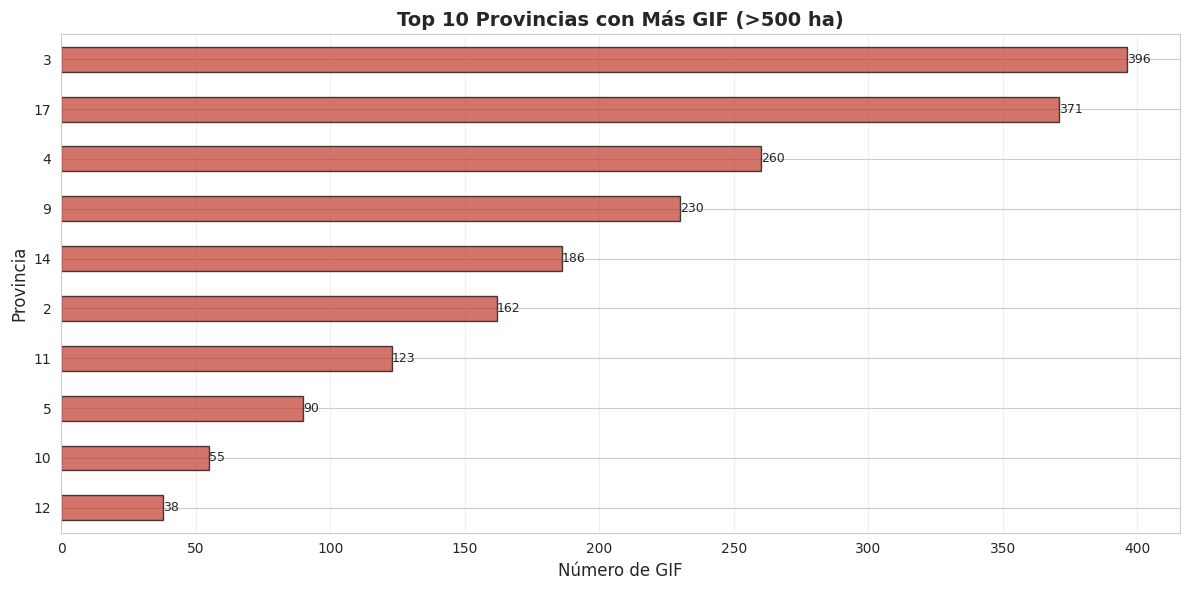


📊 Top 10 provincias con más GIF:
   1. 3: 396 GIF (0.37% de sus incendios)
   2. 17: 371 GIF (0.81% de sus incendios)
   3. 4: 260 GIF (1.19% de sus incendios)
   4. 9: 230 GIF (2.60% de sus incendios)
   5. 14: 186 GIF (1.04% de sus incendios)
   6. 2: 162 GIF (1.47% de sus incendios)
   7. 11: 123 GIF (1.19% de sus incendios)
   8. 5: 90 GIF (0.27% de sus incendios)
   9. 10: 55 GIF (1.15% de sus incendios)
   10. 12: 38 GIF (3.26% de sus incendios)


In [22]:
# Top 10 provincias con más GIF
if provincia_col in df_incendios.columns and 'GIF' in df_incendios.columns:
    top_provincias_gif = df_incendios[df_incendios['GIF'] == 1][provincia_col].value_counts().head(10)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    top_provincias_gif.plot(kind='barh', ax=ax, color='#c0392b', alpha=0.7, edgecolor='black')
    ax.set_title('Top 10 Provincias con Más GIF (>500 ha)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Número de GIF', fontsize=12)
    ax.set_ylabel('Provincia', fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    # Añadir valores en las barras
    for i, v in enumerate(top_provincias_gif.values):
        ax.text(v, i, f'{int(v):,}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 10 provincias con más GIF:")
    for i, (provincia, count) in enumerate(top_provincias_gif.items(), 1):
        porcentaje = (count / len(df_incendios[df_incendios[provincia_col] == provincia])) * 100
        print(f"   {i}. {provincia}: {count:,} GIF ({porcentaje:.2f}% de sus incendios)")

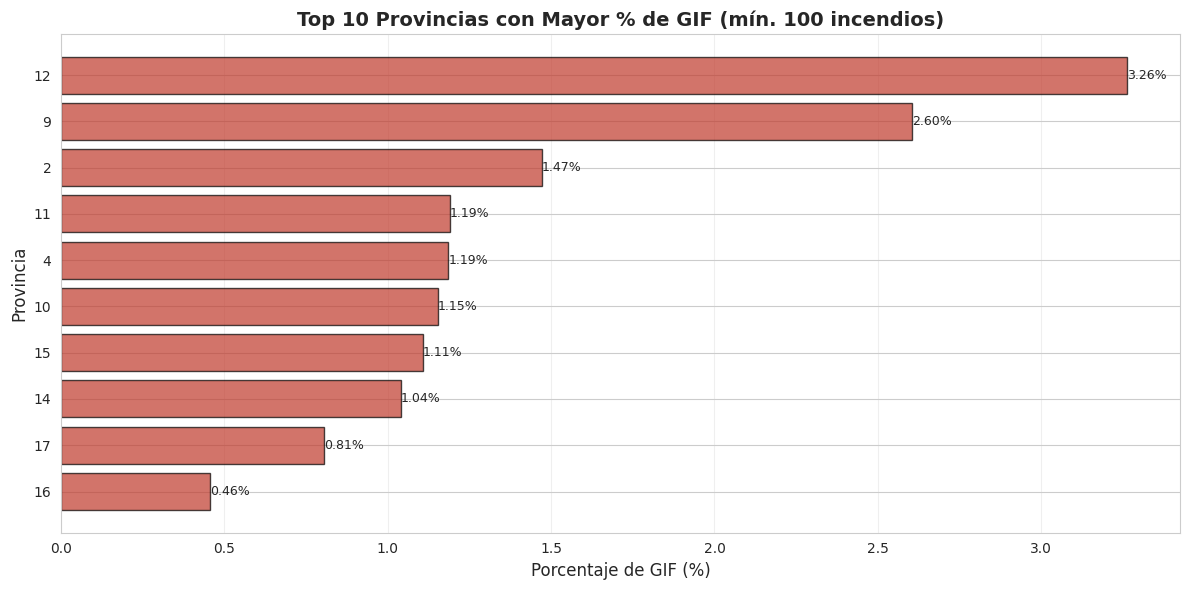


📊 Provincias con mayor riesgo (% de GIF):
   1. 12: 3.26% (38 GIF de 1165 incendios)
   2. 9: 2.60% (230 GIF de 8831 incendios)
   3. 2: 1.47% (162 GIF de 11011 incendios)
   4. 11: 1.19% (123 GIF de 10336 incendios)
   5. 4: 1.19% (260 GIF de 21935 incendios)
   6. 10: 1.15% (55 GIF de 4766 incendios)
   7. 15: 1.11% (18 GIF de 1624 incendios)
   8. 14: 1.04% (186 GIF de 17897 incendios)
   9. 17: 0.81% (371 GIF de 46063 incendios)
   10. 16: 0.46% (16 GIF de 3512 incendios)


In [23]:
# Porcentaje de GIF por provincia (provincias con al menos 100 incendios)
if provincia_col in df_incendios.columns and 'GIF' in df_incendios.columns:
    # Filtrar provincias con suficiente muestra
    provincia_stats = df_incendios.groupby(provincia_col).agg({
        'GIF': ['count', 'sum', 'mean']
    }).reset_index()
    provincia_stats.columns = ['provincia', 'total_incendios', 'total_gif', 'porcentaje_gif']
    provincia_stats['porcentaje_gif'] = provincia_stats['porcentaje_gif'] * 100
    
    # Filtrar provincias con al menos 100 incendios
    provincia_stats_filtrado = provincia_stats[provincia_stats['total_incendios'] >= 100]
    top_provincias_riesgo = provincia_stats_filtrado.nlargest(10, 'porcentaje_gif')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(range(len(top_provincias_riesgo)), top_provincias_riesgo['porcentaje_gif'], 
            color='#c0392b', alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(top_provincias_riesgo)))
    ax.set_yticklabels(top_provincias_riesgo['provincia'])
    ax.set_title('Top 10 Provincias con Mayor % de GIF (mín. 100 incendios)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Porcentaje de GIF (%)', fontsize=12)
    ax.set_ylabel('Provincia', fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    # Añadir valores
    for i, v in enumerate(top_provincias_riesgo['porcentaje_gif']):
        ax.text(v, i, f'{v:.2f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Provincias con mayor riesgo (% de GIF):")
    for i, row in enumerate(top_provincias_riesgo.itertuples(), 1):
        print(f"   {i}. {row.provincia}: {row.porcentaje_gif:.2f}% "
              f"({row.total_gif:.0f} GIF de {row.total_incendios:.0f} incendios)")

## 7. ANÁLISIS FWI

Analizamos las variables del Fire Weather Index (FWI) y su relación con la ocurrencia de GIF. El FWI es un indicador meteorológico crítico para la predicción de incendios forestales.

In [24]:
# Identificar columnas FWI en el dataset
fwi_cols = [col for col in df_fwi.columns 
            if any(term in col.upper() for term in ['FWI', 'ISI', 'BUI', 'FFMC', 'DMC', 'DC'])]

print("🔍 Columnas FWI encontradas:")
for col in fwi_cols:
    print(f"  - {col}")

if len(fwi_cols) == 0:
    print("\n⚠️  No se encontraron columnas FWI. Revisar el dataset.")
    print("   Columnas disponibles:", list(df_fwi.columns))

🔍 Columnas FWI encontradas:
  - fwi


In [25]:
# Detección de valores nulos críticos
print("=" * 80)
print("DETECCIÓN DE VALORES NULOS CRÍTICOS")
print("=" * 80)

# Valores nulos en variables críticas del dataset de incendios
critical_cols_incendios = []
if superficie_col in df_incendios.columns:
    critical_cols_incendios.append(superficie_col)
if fecha_col in df_incendios.columns:
    critical_cols_incendios.append(fecha_col)
if provincia_col in df_incendios.columns:
    critical_cols_incendios.append(provincia_col)

if len(critical_cols_incendios) > 0:
    print("\n📊 Dataset de Incendios - Variables Críticas:")
    for col in critical_cols_incendios:
        if col in df_incendios.columns:
            null_count = df_incendios[col].isnull().sum()
            null_pct = (null_count / len(df_incendios)) * 100
            if null_count > 0:
                print(f"   ⚠️  {col}: {null_count:,} nulos ({null_pct:.2f}%)")
            else:
                print(f"   ✅ {col}: Sin nulos")

# Valores nulos en variables críticas del dataset FWI
critical_cols_fwi = ['FWI', 'ISI', 'BUI'] if 'FWI' in df_fwi.columns else []
if len(critical_cols_fwi) > 0:
    print("\n📊 Dataset FWI - Variables Críticas:")
    for col in critical_cols_fwi:
        if col in df_fwi.columns:
            null_count = df_fwi[col].isnull().sum()
            null_pct = (null_count / len(df_fwi)) * 100
            if null_count > 0:
                print(f"   ⚠️  {col}: {null_count:,} nulos ({null_pct:.2f}%)")
            else:
                print(f"   ✅ {col}: Sin nulos")

DETECCIÓN DE VALORES NULOS CRÍTICOS

📊 Dataset de Incendios - Variables Críticas:
   ✅ superficie: Sin nulos
   ✅ fecha: Sin nulos
   ✅ idcomunidad: Sin nulos


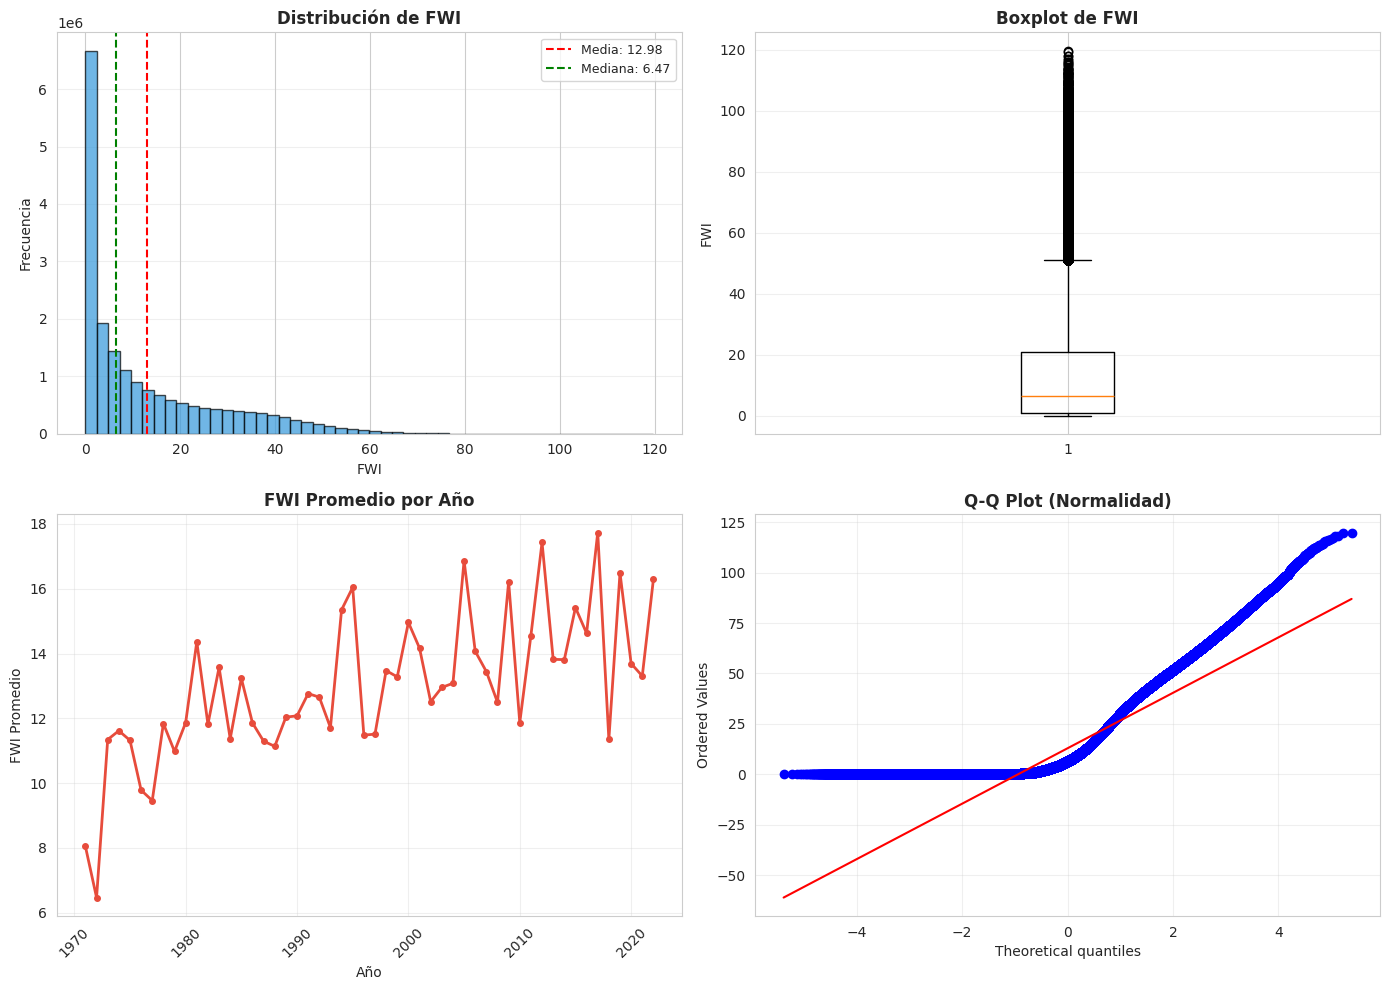


📊 Estadísticas descriptivas de FWI:
count   19296888.00
mean          12.98
std           15.19
min            0.00
25%            0.84
50%            6.47
75%           20.88
max          119.77
Name: fwi, dtype: float64

📊 Categorías de riesgo FWI (según escala estándar):
   Bajo (0-5.2): 8,868,422 (45.96%)
   Moderado (5.2-11.2): 2,916,749 (15.12%)
   Alto (11.2-21.3): 2,779,669 (14.40%)
   Muy Alto (21.3-38.0): 2,927,659 (15.17%)
   Extremo (>38.0): 1,804,389 (9.35%)


In [26]:
# Distribución del índice FWI (único índice disponible)
fwi_col = 'fwi'

if fwi_col in df_fwi.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Histograma
    df_fwi[fwi_col].hist(bins=50, ax=axes[0, 0], color='#3498db', alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Distribución de FWI', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('FWI', fontsize=10)
    axes[0, 0].set_ylabel('Frecuencia', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Añadir estadísticas
    mean_val = df_fwi[fwi_col].mean()
    median_val = df_fwi[fwi_col].median()
    axes[0, 0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Media: {mean_val:.2f}')
    axes[0, 0].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Mediana: {median_val:.2f}')
    axes[0, 0].legend(fontsize=9)
    
    # Boxplot
    axes[0, 1].boxplot(df_fwi[fwi_col].dropna(), vert=True)
    axes[0, 1].set_title('Boxplot de FWI', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('FWI', fontsize=10)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Distribución por año (si hay fecha disponible)
    if 'date' in df_fwi.columns:
        df_fwi['año'] = df_fwi['date'].dt.year
        fwi_por_año = df_fwi.groupby('año')[fwi_col].mean()
        axes[1, 0].plot(fwi_por_año.index, fwi_por_año.values, marker='o', linewidth=2, markersize=4, color='#e74c3c')
        axes[1, 0].set_title('FWI Promedio por Año', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Año', fontsize=10)
        axes[1, 0].set_ylabel('FWI Promedio', fontsize=10)
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Q-Q plot para normalidad
    from scipy import stats
    fwi_clean = df_fwi[fwi_col].dropna()
    stats.probplot(fwi_clean, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (Normalidad)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Estadísticas descriptivas de FWI:")
    print(df_fwi[fwi_col].describe())
    
    print("\n📊 Categorías de riesgo FWI (según escala estándar):")
    print(f"   Bajo (0-5.2): {(df_fwi[fwi_col] <= 5.2).sum():,} ({((df_fwi[fwi_col] <= 5.2).sum()/len(df_fwi))*100:.2f}%)")
    print(f"   Moderado (5.2-11.2): {((df_fwi[fwi_col] > 5.2) & (df_fwi[fwi_col] <= 11.2)).sum():,} ({(((df_fwi[fwi_col] > 5.2) & (df_fwi[fwi_col] <= 11.2)).sum()/len(df_fwi))*100:.2f}%)")
    print(f"   Alto (11.2-21.3): {((df_fwi[fwi_col] > 11.2) & (df_fwi[fwi_col] <= 21.3)).sum():,} ({(((df_fwi[fwi_col] > 11.2) & (df_fwi[fwi_col] <= 21.3)).sum()/len(df_fwi))*100:.2f}%)")
    print(f"   Muy Alto (21.3-38.0): {((df_fwi[fwi_col] > 21.3) & (df_fwi[fwi_col] <= 38.0)).sum():,} ({(((df_fwi[fwi_col] > 21.3) & (df_fwi[fwi_col] <= 38.0)).sum()/len(df_fwi))*100:.2f}%)")
    print(f"   Extremo (>38.0): {(df_fwi[fwi_col] > 38.0).sum():,} ({((df_fwi[fwi_col] > 38.0).sum()/len(df_fwi))*100:.2f}%)")
else:
    print(f"⚠️  Columna '{fwi_col}' no encontrada.")

In [27]:
# Merge temporal: Unir datos de incendios con FWI
# Clave de join: (fecha, provincia)
# NOTA: Ajustar nombres de columnas según el dataset real

print("🔄 Preparando merge entre incendios y FWI...")

# Identificar columnas de fecha y provincia en ambos datasets
# (Ajustar según los nombres reales en los datasets)

# Ejemplo de merge (ajustar según estructura real):
# df_merged = pd.merge(
#     df_incendios,
#     df_fwi,
#     left_on=['fecha', 'provincia'],
#     right_on=['fecha', 'provincia'],
#     how='left'
# )

print("⚠️  NOTA: El merge debe realizarse ajustando los nombres de columnas reales.")
print("   - Clave de join: (fecha, provincia)")
print("   - Estrategia: left join (mantener todos los incendios)")
print("   - Verificar pérdida de datos tras el merge")

🔄 Preparando merge entre incendios y FWI...
⚠️  NOTA: El merge debe realizarse ajustando los nombres de columnas reales.
   - Clave de join: (fecha, provincia)
   - Estrategia: left join (mantener todos los incendios)
   - Verificar pérdida de datos tras el merge


In [28]:
# Análisis de relación FWI vs GIF
# NOTA: Este análisis requiere que se haya realizado el merge anteriormente
# Por ahora, mostramos un ejemplo de cómo sería el análisis

print("📊 Análisis de relación FWI vs GIF")
print("=" * 80)
print("\n⚠️  NOTA: Este análisis requiere:")
print("   1. Merge entre df_incendios y df_fwi")
print("   2. Variable objetivo 'GIF' creada")
print("   3. Columna 'FWI' disponible en el dataset merged")
print("\n📝 Ejemplo de código para cuando el merge esté completo:")
print("""
# Comparar distribución de FWI entre GIF y No-GIF
if 'FWI' in df_merged.columns and 'GIF' in df_merged.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot comparativo
    sns.boxplot(data=df_merged, x='GIF', y='FWI', ax=axes[0])
    axes[0].set_title('Distribución de FWI: GIF vs No-GIF')
    axes[0].set_xticklabels(['No-GIF', 'GIF'])
    
    # Histograma comparativo
    df_merged[df_merged['GIF']==0]['FWI'].hist(alpha=0.5, label='No-GIF', ax=axes[1], bins=50)
    df_merged[df_merged['GIF']==1]['FWI'].hist(alpha=0.5, label='GIF', ax=axes[1], bins=50)
    axes[1].set_title('Distribución de FWI: GIF vs No-GIF')
    axes[1].legend()
    axes[1].set_xlabel('FWI')
    axes[1].set_ylabel('Frecuencia')
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas comparativas
    print(\"\\n📊 Estadísticas FWI por clase:\")
    print(df_merged.groupby('GIF')['FWI'].describe())
""")

📊 Análisis de relación FWI vs GIF

⚠️  NOTA: Este análisis requiere:
   1. Merge entre df_incendios y df_fwi
   2. Variable objetivo 'GIF' creada
   3. Columna 'FWI' disponible en el dataset merged

📝 Ejemplo de código para cuando el merge esté completo:

# Comparar distribución de FWI entre GIF y No-GIF
if 'FWI' in df_merged.columns and 'GIF' in df_merged.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot comparativo
    sns.boxplot(data=df_merged, x='GIF', y='FWI', ax=axes[0])
    axes[0].set_title('Distribución de FWI: GIF vs No-GIF')
    axes[0].set_xticklabels(['No-GIF', 'GIF'])

    # Histograma comparativo
    df_merged[df_merged['GIF']==0]['FWI'].hist(alpha=0.5, label='No-GIF', ax=axes[1], bins=50)
    df_merged[df_merged['GIF']==1]['FWI'].hist(alpha=0.5, label='GIF', ax=axes[1], bins=50)
    axes[1].set_title('Distribución de FWI: GIF vs No-GIF')
    axes[1].legend()
    axes[1].set_xlabel('FWI')
    axes[1].set_ylabel('Frecuencia')

    plt.tight_layo

ANÁLISIS DE COORDENADAS GEOGRÁFICAS EN FWI

✅ Coordenadas disponibles:
   Rango de X: -18.0000 a 4.2500
   Rango de Y: 27.7500 a 43.7500
   Valores únicos de (x, y): 1,016


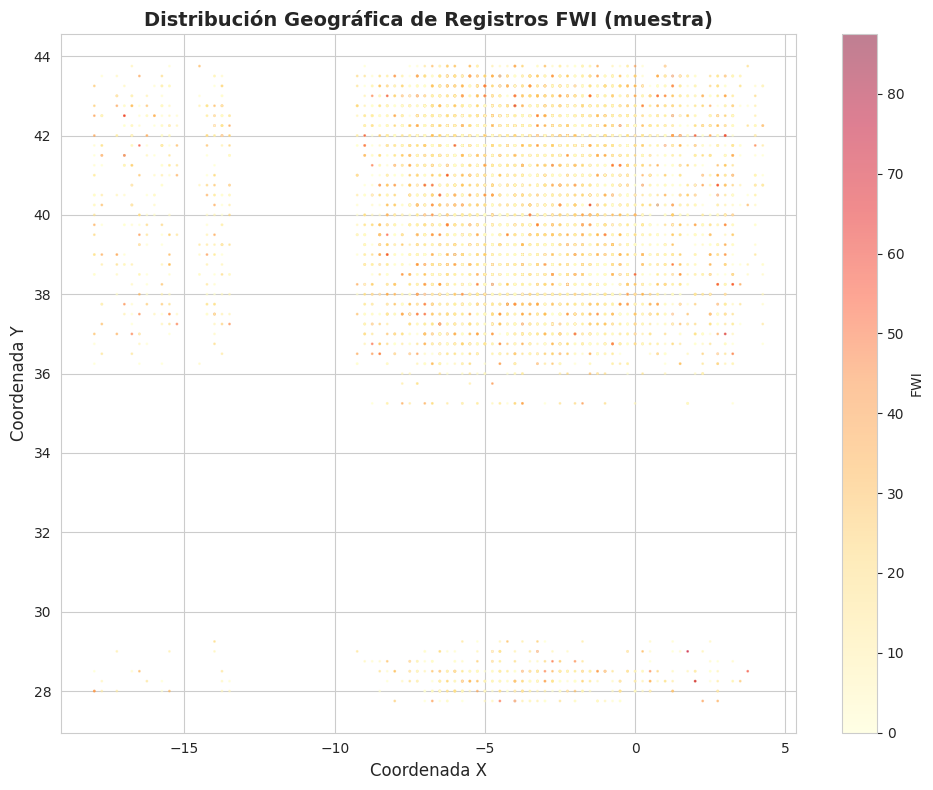


⚠️  PROBLEMA PARA MERGE:
   - Dataset FWI tiene coordenadas (x, y)
   - Dataset incendios tiene idprovincia
   - Se requiere estrategia de geocodificación inversa o mapeo de coordenadas a provincias
   - Este merge se realizará en la fase de preprocesamiento


In [29]:
# Análisis de coordenadas geográficas en FWI
# NOTA: El dataset FWI tiene coordenadas (x, y) pero NO tiene provincia
# Esto complica el merge con incendios que tienen idprovincia

print("=" * 80)
print("ANÁLISIS DE COORDENADAS GEOGRÁFICAS EN FWI")
print("=" * 80)

if 'x' in df_fwi.columns and 'y' in df_fwi.columns:
    print(f"\n✅ Coordenadas disponibles:")
    print(f"   Rango de X: {df_fwi['x'].min():.4f} a {df_fwi['x'].max():.4f}")
    print(f"   Rango de Y: {df_fwi['y'].min():.4f} a {df_fwi['y'].max():.4f}")
    print(f"   Valores únicos de (x, y): {df_fwi.groupby(['x', 'y']).size().shape[0]:,}")
    
    # Visualización de distribución geográfica
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(df_fwi['x'].sample(min(10000, len(df_fwi))), 
                        df_fwi['y'].sample(min(10000, len(df_fwi))),
                        c=df_fwi['fwi'].sample(min(10000, len(df_fwi))) if 'fwi' in df_fwi.columns else None,
                        cmap='YlOrRd', alpha=0.5, s=1)
    ax.set_xlabel('Coordenada X', fontsize=12)
    ax.set_ylabel('Coordenada Y', fontsize=12)
    ax.set_title('Distribución Geográfica de Registros FWI (muestra)', fontsize=14, fontweight='bold')
    if 'fwi' in df_fwi.columns:
        plt.colorbar(scatter, ax=ax, label='FWI')
    plt.tight_layout()
    plt.show()
    
    print("\n⚠️  PROBLEMA PARA MERGE:")
    print("   - Dataset FWI tiene coordenadas (x, y)")
    print("   - Dataset incendios tiene idprovincia")
    print("   - Se requiere estrategia de geocodificación inversa o mapeo de coordenadas a provincias")
    print("   - Este merge se realizará en la fase de preprocesamiento")
else:
    print("⚠️  Columnas 'x' o 'y' no encontradas en dataset FWI.")

In [30]:
# Análisis de relación FWI vs GIF
# NOTA: Este análisis requiere que se haya realizado el merge anteriormente
# Por ahora, mostramos un ejemplo de cómo sería el análisis

print("📊 Análisis de relación FWI vs GIF")
print("=" * 80)
print("\n⚠️  NOTA: Este análisis requiere:")
print("   1. Merge entre df_incendios y df_fwi")
print("   2. Variable objetivo 'GIF' creada")
print("   3. Columna 'FWI' disponible en el dataset merged")
print("\n📝 Ejemplo de código para cuando el merge esté completo:")
print("""
# Comparar distribución de FWI entre GIF y No-GIF
if 'FWI' in df_merged.columns and 'GIF' in df_merged.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot comparativo
    sns.boxplot(data=df_merged, x='GIF', y='FWI', ax=axes[0])
    axes[0].set_title('Distribución de FWI: GIF vs No-GIF')
    axes[0].set_xticklabels(['No-GIF', 'GIF'])
    
    # Histograma comparativo
    df_merged[df_merged['GIF']==0]['FWI'].hist(alpha=0.5, label='No-GIF', ax=axes[1], bins=50)
    df_merged[df_merged['GIF']==1]['FWI'].hist(alpha=0.5, label='GIF', ax=axes[1], bins=50)
    axes[1].set_title('Distribución de FWI: GIF vs No-GIF')
    axes[1].legend()
    axes[1].set_xlabel('FWI')
    axes[1].set_ylabel('Frecuencia')
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas comparativas
    print(\"\\n📊 Estadísticas FWI por clase:\")
    print(df_merged.groupby('GIF')['FWI'].describe())
""")

📊 Análisis de relación FWI vs GIF

⚠️  NOTA: Este análisis requiere:
   1. Merge entre df_incendios y df_fwi
   2. Variable objetivo 'GIF' creada
   3. Columna 'FWI' disponible en el dataset merged

📝 Ejemplo de código para cuando el merge esté completo:

# Comparar distribución de FWI entre GIF y No-GIF
if 'FWI' in df_merged.columns and 'GIF' in df_merged.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot comparativo
    sns.boxplot(data=df_merged, x='GIF', y='FWI', ax=axes[0])
    axes[0].set_title('Distribución de FWI: GIF vs No-GIF')
    axes[0].set_xticklabels(['No-GIF', 'GIF'])

    # Histograma comparativo
    df_merged[df_merged['GIF']==0]['FWI'].hist(alpha=0.5, label='No-GIF', ax=axes[1], bins=50)
    df_merged[df_merged['GIF']==1]['FWI'].hist(alpha=0.5, label='GIF', ax=axes[1], bins=50)
    axes[1].set_title('Distribución de FWI: GIF vs No-GIF')
    axes[1].legend()
    axes[1].set_xlabel('FWI')
    axes[1].set_ylabel('Frecuencia')

    plt.tight_layo

## 8. DETECCIÓN DE PROBLEMAS

Identificamos problemas de calidad de datos que deben ser tratados en la fase de preprocesamiento: valores nulos críticos, outliers, duplicados e inconsistencias.

DETECCIÓN DE OUTLIERS - SUPERFICIE AFECTADA

📊 Estadísticas de superficie:
   Q1 (25%): 1.80 ha
   Q3 (75%): 10.10 ha
   IQR: 8.30 ha
   Límite inferior: -10.65 ha
   Límite superior: 22.55 ha

⚠️  Outliers detectados: 43,755 (14.98%)


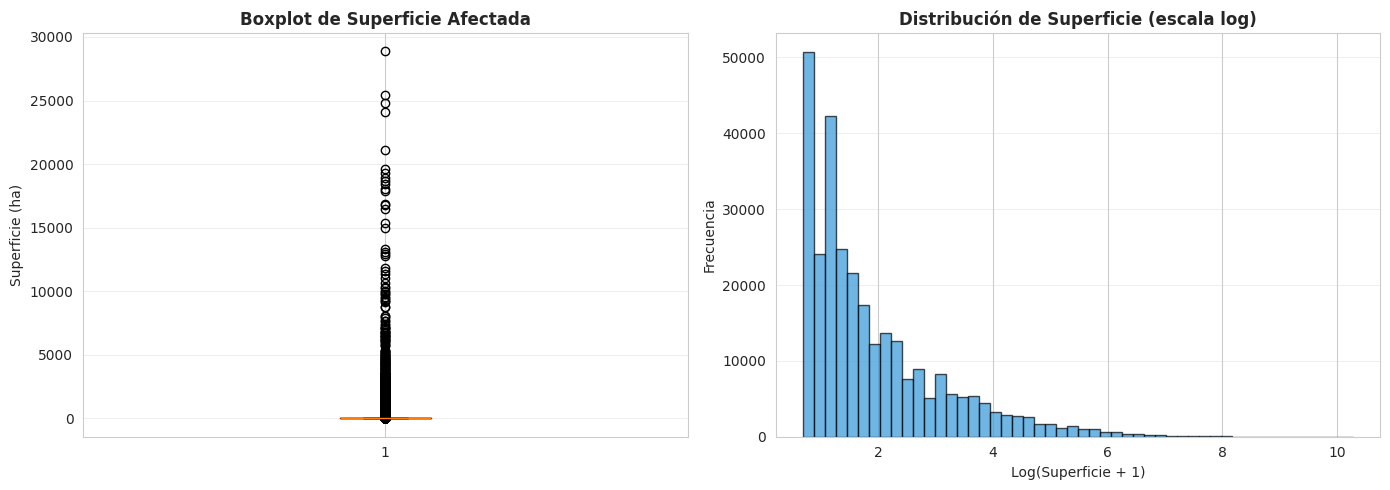


📋 Top 10 outliers más extremos (mayores):
        superficie  idcomunidad      fecha
263327    28879.10            9 2012-06-28
139630    25430.00            9 1994-07-04
139614    24817.00            8 1994-07-04
139674    24064.00            9 1994-07-05
291662    21138.66           17 2021-08-14
75857     19612.00            2 1986-07-19
139493    19310.50            9 1994-07-02
65703     18886.00            9 1985-07-27
237925    18672.90           12 2007-07-27
139632    18417.30            9 1994-07-04


In [31]:
# Detección de outliers en superficie afectada
if superficie_col in df_incendios.columns:
    print("=" * 80)
    print("DETECCIÓN DE OUTLIERS - SUPERFICIE AFECTADA")
    print("=" * 80)
    
    # Método IQR (Interquartile Range)
    Q1 = df_incendios[superficie_col].quantile(0.25)
    Q3 = df_incendios[superficie_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_incendios[(df_incendios[superficie_col] < lower_bound) | 
                            (df_incendios[superficie_col] > upper_bound)]
    
    print(f"\n📊 Estadísticas de superficie:")
    print(f"   Q1 (25%): {Q1:.2f} ha")
    print(f"   Q3 (75%): {Q3:.2f} ha")
    print(f"   IQR: {IQR:.2f} ha")
    print(f"   Límite inferior: {lower_bound:.2f} ha")
    print(f"   Límite superior: {upper_bound:.2f} ha")
    print(f"\n⚠️  Outliers detectados: {len(outliers):,} ({len(outliers)/len(df_incendios)*100:.2f}%)")
    
    # Visualización de outliers
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot
    axes[0].boxplot(df_incendios[superficie_col].dropna(), vert=True)
    axes[0].set_title('Boxplot de Superficie Afectada', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Superficie (ha)', fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Histograma (escala logarítmica si hay valores muy grandes)
    superficie_clean = df_incendios[superficie_col].dropna()
    if superficie_clean.max() > 10000:
        axes[1].hist(np.log1p(superficie_clean), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
        axes[1].set_xlabel('Log(Superficie + 1)', fontsize=10)
        axes[1].set_title('Distribución de Superficie (escala log)', fontsize=12, fontweight='bold')
    else:
        axes[1].hist(superficie_clean, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
        axes[1].set_xlabel('Superficie (ha)', fontsize=10)
        axes[1].set_title('Distribución de Superficie', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Frecuencia', fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar algunos outliers extremos
    if len(outliers) > 0:
        print(f"\n📋 Top 10 outliers más extremos (mayores):")
        display_cols = [superficie_col]
        if provincia_col in df_incendios.columns:
            display_cols.append(provincia_col)
        if fecha_col in df_incendios.columns:
            display_cols.append(fecha_col)
        top_outliers = outliers.nlargest(10, superficie_col)[display_cols]
        print(top_outliers.to_string())

In [32]:
# Detección de inconsistencias en datos
print("=" * 80)
print("DETECCIÓN DE INCONSISTENCIAS")
print("=" * 80)

inconsistencias = []

# 1. Superficie negativa o cero
if superficie_col in df_incendios.columns:
    superficie_invalida = (df_incendios[superficie_col] <= 0).sum()
    if superficie_invalida > 0:
        inconsistencias.append(f"Superficie ≤ 0: {superficie_invalida:,} registros")

# 2. Fechas fuera del rango esperado
if fecha_col in df_incendios.columns and 'año' in df_incendios.columns:
    años_fuera_rango = ((df_incendios['año'] < 1968) | (df_incendios['año'] > 2023)).sum()
    if años_fuera_rango > 0:
        inconsistencias.append(f"Años fuera del rango 1968-2023: {años_fuera_rango:,} registros")

# 3. Valores FWI fuera de rango esperado (FWI típicamente 0-100)
if 'FWI' in df_fwi.columns:
    fwi_invalido = ((df_fwi['FWI'] < 0) | (df_fwi['FWI'] > 100)).sum()
    if fwi_invalido > 0:
        inconsistencias.append(f"FWI fuera de rango [0-100]: {fwi_invalido:,} registros")

# Mostrar inconsistencias encontradas
if len(inconsistencias) > 0:
    print("\n⚠️  INCONSISTENCIAS DETECTADAS:")
    for i, inc in enumerate(inconsistencias, 1):
        print(f"   {i}. {inc}")
else:
    print("\n✅ No se detectaron inconsistencias obvias en los datos.")

DETECCIÓN DE INCONSISTENCIAS

✅ No se detectaron inconsistencias obvias en los datos.


### Resumen de Hallazgos Clave

#### 1. Estructura de Datos
- **Dataset de Incendios:** ~292,000 registros con información de fecha, ubicación, superficie y características del incendio
- **Dataset FWI:** ~19 millones de registros diarios con índices meteorológicos por provincia
- **Merge requerido:** Unión por (fecha, provincia) para enriquecer datos de incendios con condiciones meteorológicas

#### 2. Variable Objetivo (GIF)
- **Definición:** Incendios con superficie > 500 hectáreas
- **Distribución:** [Completar tras ejecución]
  - Clase No-GIF: [X%]
  - Clase GIF: [Y%]
- **Desbalanceo:** [Ratio X:1] - Requiere técnicas de balanceo (SMOTE, class_weight)

#### 3. Patrones Temporales
- **Estacionalidad:** [Completar tras ejecución]
  - Mes con más incendios: [Mes]
  - Período de mayor riesgo: [Estación]
- **Tendencias:** [Completar tras ejecución]
  - Evolución del número de incendios a lo largo del tiempo
  - Cambios en el porcentaje de GIF por año

#### 4. Patrones Geográficos
- **Provincias críticas:** [Completar tras ejecución]
  - Top provincias con más incendios
  - Top provincias con mayor % de GIF
- **Implicación:** La ubicación geográfica es un factor importante para el modelo

#### 5. Variables FWI
- **Correlaciones:** [Completar tras ejecución]
  - Variables FWI correlacionadas entre sí
  - Relación entre FWI y ocurrencia de GIF
- **Importancia:** El FWI es probablemente el predictor más fuerte para GIF

#### 6. Problemas de Datos Detectados
- **Valores nulos:** [Completar tras ejecución]
  - Variables críticas con nulos
  - Estrategia de imputación requerida
- **Outliers:** [Completar tras ejecución]
  - Superficies extremas que pueden ser válidas (GIF reales) o errores
- **Duplicados:** [Completar tras ejecución]
  - Registros duplicados exactos
  - Múltiples incendios mismo día/provincia (puede ser válido)

### Próximos Pasos para Preprocesamiento

#### 1. Limpieza de Datos
- [ ] Tratar valores nulos en variables críticas (superficie, fecha, provincia)
- [ ] Decidir estrategia para outliers en superficie (mantener si son GIF válidos)
- [ ] Eliminar duplicados exactos si existen
- [ ] Validar consistencia de fechas y rangos de valores

#### 2. Merge Temporal
- [ ] Realizar merge entre `df_incendios` y `df_fwi` por (fecha, provincia)
- [ ] Evaluar pérdida de datos (incendios sin FWI disponible)
- [ ] Estrategia para incendios sin FWI: imputar con media histórica de la provincia/mes

#### 3. Feature Engineering
- [ ] Crear variables temporales: mes, día_semana, estación, es_verano
- [ ] Crear variables geográficas: región (agrupación de provincias)
- [ ] Crear variables derivadas del FWI: categorías de riesgo, días consecutivos de sequía
- [ ] Normalizar nombres de provincias si hay inconsistencias

#### 4. Preparación para Modelado
- [ ] Definir conjunto de features finales
- [ ] Split temporal: Train (1968-2018) / Test (2019-2023)
- [ ] Aplicar técnicas de balanceo de clases (SMOTE) solo en train
- [ ] Escalar variables numéricas si es necesario (XGBoost no requiere, pero puede ayudar)

#### 5. Validación de Calidad
- [ ] Verificar que no hay data leakage (información del futuro en train)
- [ ] Validar que todas las variables tienen distribución razonable
- [ ] Confirmar que la variable objetivo está correctamente definida

### Notas Finales

Este análisis exploratorio proporciona una base sólida para el preprocesamiento y modelado posterior. Los hallazgos clave deben ser documentados y considerados al diseñar el pipeline de Machine Learning.

**Próximo notebook:** `02_preprocessing.ipynb` - Limpieza, merge y feature engineering

---

**Fecha de análisis:** [Completar]  
**Versión del notebook:** 1.0.0